In [39]:
from sys import displayhook

import matplotlib.pyplot as plt
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
default_new_runsolver = pd.read_csv("storage_alice/new_runsolver_default_config/default_new_runsovler340.csv")
smac3_new_enbumbent = pd.read_csv("storage_alice/new_runsolver_default_config_smac3/default_new_runsovler340_smac3.csv")

In [5]:
display(default_new_runsolver.head())

,Unnamed: 0,Status,Runtime,Runlength,quality,seed,File
0,0,UNSAT,158.555,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
1,1,UNSAT,323.454,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
2,2,UNSAT,486.328,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
3,3,UNSAT,921.222,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
4,4,UNSAT,991.593,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...


In [6]:
display(smac3_new_enbumbent.head())

,Unnamed: 0,Status,Runtime,Runlength,quality,seed,File
0,0,UNSAT,110.306,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
1,1,UNSAT,154.893,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
2,2,UNSAT,346.081,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
3,3,UNSAT,563.916,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...
4,4,UNSAT,629.656,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...


In [8]:
diff1 = set(default_new_runsolver["File"].unique()) - set(smac3_new_enbumbent["File"].unique())
diff2 = set(smac3_new_enbumbent["File"].unique()) - set(default_new_runsolver["File"].unique())
print(diff1)
print(diff2)

set()
set()


Both ran on all files, no instances missing

# Only training set comparison

In [73]:
def get_training_subframe(full_fram):
    train = []

    with open("./aclib2/instances/mip/sets/SDPdMLPa-MIPVerify/training.txt") as file:
        line = file.readline()
        while line:
            # number = line.split("/")[-1][4:-4]
            # train.append(f"./storage/default7/{number}.txt")
            train.append(line.rstrip().replace("/home/skippybal/Projects/THESIS/", ""))
            # print(number)
            # print(line.strip())
            line = file.readline()
        file.close()

    print(train)
    train_dataframe = full_fram[full_fram["File"].isin(train)]
    # display(train_dataframe)
    return train_dataframe


In [74]:
training_default = get_training_subframe(default_new_runsolver)
smac3_frame = get_training_subframe(smac3_new_enbumbent)

['aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_1.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_4.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_5.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_6.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_7.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_11.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_12.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_13.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_14.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_15.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_18.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_20.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_21.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_22.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_23.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_24.lp', 'aclib2/instances/mip/data/SDPdMLPa-MIPVerify/mip_26.lp', 'aclib2/instances/

In [21]:
print(len(training_default))

92


In [25]:
print(training_default["Status"].value_counts())
print(smac3_frame["Status"].value_counts())

Status
SUCCESS    63
UNSAT      22
TIMEOUT     7
Name: count, dtype: int64
Status
SUCCESS    65
UNSAT      22
TIMEOUT     5
Name: count, dtype: int64


The new one found by smac 3 actually has fewer timouts, with 2 of the timeouts now becomming successes

count      92.00000
mean     1886.93163
std      2757.33373
min        10.56320
25%       115.27425
50%       484.47550
75%      2758.05500
max      9601.24000
Name: Runtime, dtype: float64
Status
SUCCESS    63
UNSAT      22
TIMEOUT     7
Name: count, dtype: int64


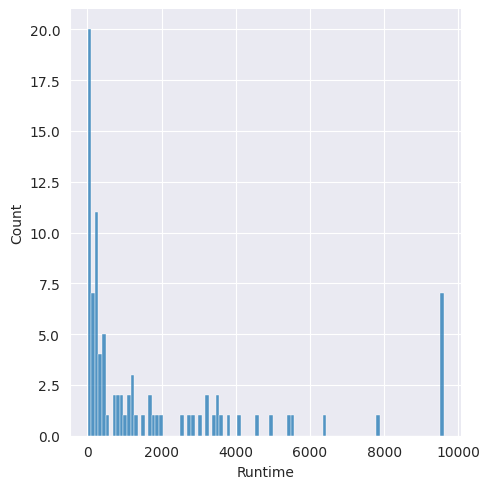

In [75]:
sns.displot(training_default, x="Runtime", bins=100)
print(training_default["Runtime"].describe())
print(training_default["Status"].value_counts())

This is really odd, as the default from alice seems to have a worse distribution with more timeouts than when I ran it on my own laptop...

# TODO: check alice default vs my machine.... as it seems there is a high machine dependency as the mean is also 1886 compared to the 1100 on my machine... (already also in compare tho...)
Mention that the fist smac runs where actually from my own machine and newer ones are from alice

## SMAC3

count      92.000000
mean     1478.480316
std      2476.789579
min         9.915840
25%        94.810000
50%       428.078000
75%      1515.485000
max      9601.220000
Name: Runtime, dtype: float64
Status
SUCCESS    65
UNSAT      22
TIMEOUT     5
Name: count, dtype: int64


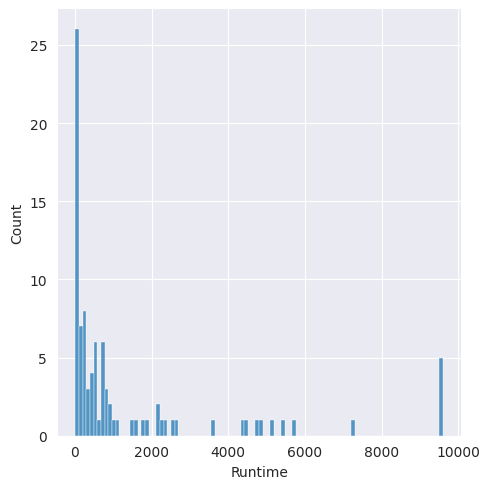

In [76]:
sns.displot(smac3_frame, x="Runtime", bins=100)
print(smac3_frame["Runtime"].describe())
print(smac3_frame["Status"].value_counts())

## Compare

In [36]:
result_frame = pd.merge(training_default, smac3_frame, how="left", on="File")
display(result_frame)
# print(result_frame)

,Unnamed: 0_x,Status_x,Runtime_x,Runlength_x,quality_x,seed_x,File,Unnamed: 0_y,Status_y,Runtime_y,Runlength_y,quality_y,seed_y
0,0,UNSAT,158.555,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,0,UNSAT,110.306,0,0,-1
1,1,UNSAT,323.454,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1,UNSAT,154.893,0,0,-1
2,2,UNSAT,486.328,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,2,UNSAT,346.081,0,0,-1
3,3,UNSAT,921.222,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,3,UNSAT,563.916,0,0,-1
4,4,UNSAT,991.593,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,6,UNSAT,708.862,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,121,TIMEOUT,9601.140,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,85,SUCCESS,3652.620,0,0,-1
88,124,SUCCESS,2817.800,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,122,SUCCESS,2198.150,0,0,-1
89,133,TIMEOUT,9601.240,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,118,SUCCESS,4390.810,0,0,-1
90,153,SUCCESS,6347.580,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,145,SUCCESS,5105.980,0,0,-1


Text(0, 0.5, 'Runtime New Config')

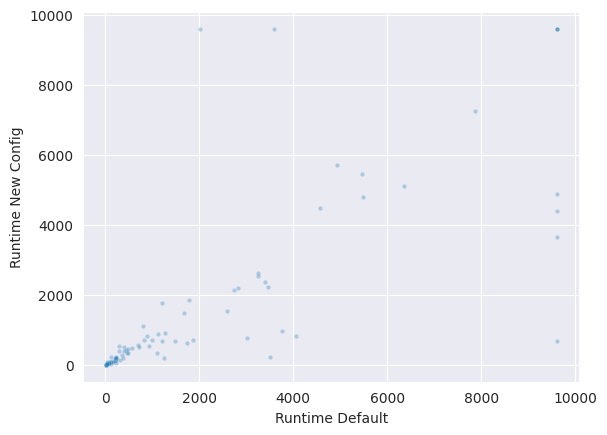

In [51]:
sns.scatterplot(data=result_frame, x="Runtime_x", y="Runtime_y", alpha=0.3, s=10)
plt.xlabel("Runtime Default")
plt.ylabel("Runtime New Config")

This is really cool to see, so SMAC3 actually does find a better configuration that has 2 timouts that perform well on the default and around 3 points that perform all (significatly) better on the default. All other points are seemingly equal or better.

## comparing PAR10

In [77]:
training_default = training_default["Runtime"].copy()
training_default[training_default >= 9600] *= 10
print(training_default.mean())

8461.59597826087


In [78]:
runtimes_smac3 = smac3_frame["Runtime"].copy()
runtimes_smac3[runtimes_smac3 >= 9600] *= 10
print(runtimes_smac3.mean())


6174.672489565218


# Now on the test set

In [56]:
def get_test_subframe(full_fram):
    test = []

    with open("./aclib2/instances/mip/sets/SDPdMLPa-MIPVerify/test.txt") as file:
        line = file.readline()
        while line:
            # number = line.split("/")[-1][4:-4]
            # train.append(f"./storage/default7/{number}.txt")
            test.append(line.rstrip().replace("/home/skippybal/Projects/THESIS/", ""))
            # print(number)
            # print(line.strip())
            line = file.readline()
        file.close()

    # print(test)
    train_dataframe = full_fram[full_fram["File"].isin(test)]
    # display(train_dataframe)
    return train_dataframe


In [80]:
test_default = get_test_subframe(default_new_runsolver)
test_smac3 = get_test_subframe(smac3_new_enbumbent)
print(len(test_default))
print(len(test_smac3))

92
92


## Default on test set

count      92.000000
mean     1401.694764
std      2336.197686
min         8.573430
25%       116.391250
50%       435.259000
75%      1170.645000
max      9601.070000
Name: Runtime, dtype: float64
Status
SUCCESS    64
UNSAT      24
TIMEOUT     4
Name: count, dtype: int64


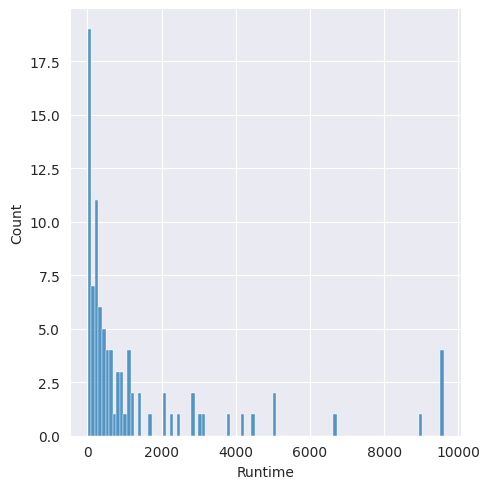

In [59]:
sns.displot(test_default, x="Runtime", bins=100)
print(test_default["Runtime"].describe())
print(test_default["Status"].value_counts())

Lower time (PAR) then on training, check this in other file, it feels really odd...

## SMAC3 new config on test set

count      92.000000
mean     1186.721291
std      2179.271574
min         8.436680
25%        86.220300
50%       312.093000
75%      1010.403000
max      9601.110000
Name: Runtime, dtype: float64
Status
SUCCESS    64
UNSAT      25
TIMEOUT     3
Name: count, dtype: int64


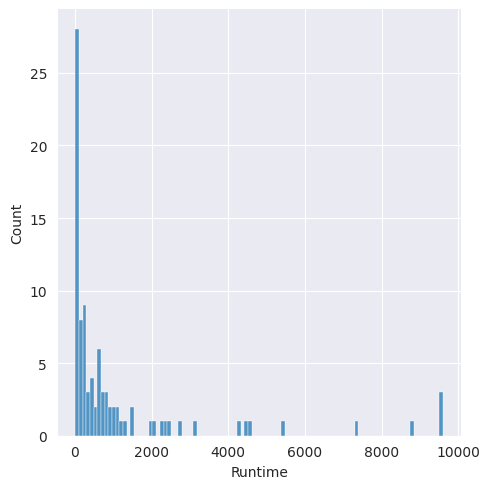

In [60]:
sns.displot(test_smac3, x="Runtime", bins=100)
print(test_smac3["Runtime"].describe())
print(test_smac3["Status"].value_counts())

Again the new config is significantly faster (PAR score) then on the default. also 1 less, timout, which mich actually be the sole reason, but well see

#TODO: Really need to write this down well, as if SMAC3 with utility works this much better in general, the portfolio approach with smac3 will likely also work much better.

## Direct compare on test

In [62]:
result_frame = pd.merge(test_default, test_smac3, how="left", on="File")
display(result_frame)
# print(result_frame)

,Unnamed: 0_x,Status_x,Runtime_x,Runlength_x,quality_x,seed_x,File,Unnamed: 0_y,Status_y,Runtime_y,Runlength_y,quality_y,seed_y
0,19,UNSAT,353.4030,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,18,UNSAT,148.682,0,0,-1
1,20,UNSAT,976.7250,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,21,UNSAT,769.530,0,0,-1
2,21,UNSAT,1162.3800,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,22,UNSAT,998.854,0,0,-1
3,23,UNSAT,402.3930,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,28,UNSAT,343.607,0,0,-1
4,24,UNSAT,36.9798,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,24,UNSAT,33.396,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,179,SUCCESS,3780.7400,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,179,SUCCESS,4510.430,0,0,-1
88,180,SUCCESS,3153.7800,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,180,SUCCESS,4254.980,0,0,-1
89,181,TIMEOUT,9601.0500,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,182,TIMEOUT,9601.110,0,0,-1
90,182,SUCCESS,8931.6700,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,181,SUCCESS,7390.350,0,0,-1


Text(0, 0.5, 'Runtime New Config')

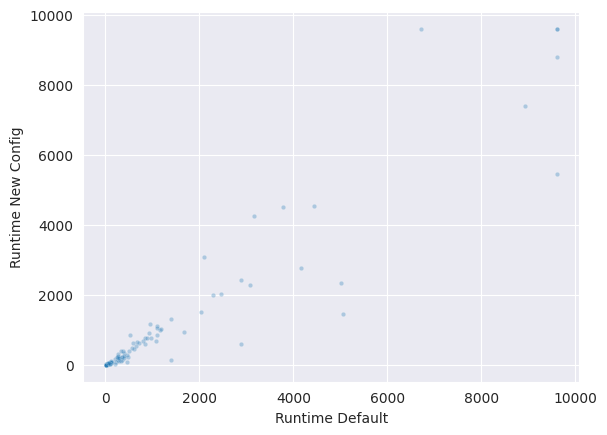

In [63]:
sns.scatterplot(data=result_frame, x="Runtime_x", y="Runtime_y", alpha=0.3, s=10)
plt.xlabel("Runtime Default")
plt.ylabel("Runtime New Config")

Okay, cool, so there are a few points better for each config again, but the default has 4 timouts, of which 2 are solved slightly faster on the new config. The new config has 3 timouts, of wich 2 are also timeouts on the default, and 1 is solver faster. for the rest of the points, its seems that the more pronounced differences are again in the region above 2000 seconds, just as in the train set. This is also where most gains in runtime seem to come from.

## Comparing PAR10

In [81]:
runtimes_test_default = test_default["Runtime"].copy()
runtimes_test_default[runtimes_test_default >= 9600] *= 10
print(runtimes_test_default.mean())

5158.628351086956


In [82]:
runtimes_smac3_default = test_smac3["Runtime"].copy()
runtimes_smac3_default[runtimes_smac3_default >= 9600] *= 10
print(runtimes_smac3_default.mean())

4004.4295516304346


# Compare on both sets

count     184.000000
mean     1644.313197
std      2560.049771
min         8.573430
25%       115.274250
50%       469.119500
75%      1807.310000
max      9601.240000
Name: Runtime, dtype: float64
Status
SUCCESS    127
UNSAT       46
TIMEOUT     11
Name: count, dtype: int64


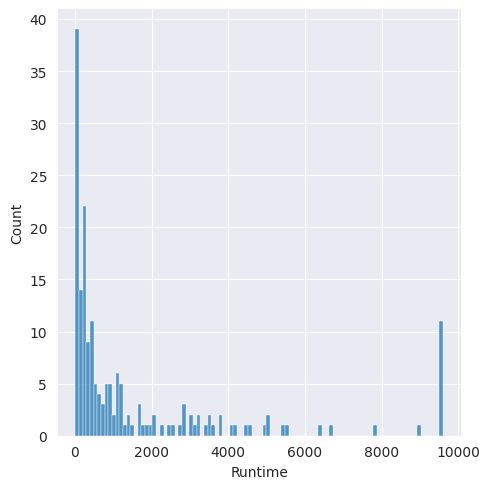

In [85]:
sns.displot(default_new_runsolver, x="Runtime", bins=100)
print(default_new_runsolver["Runtime"].describe())
print(default_new_runsolver["Status"].value_counts())

count     184.000000
mean     1332.600803
std      2330.990307
min         8.436680
25%        88.793325
50%       375.017000
75%      1082.095000
max      9601.220000
Name: Runtime, dtype: float64
Status
SUCCESS    129
UNSAT       47
TIMEOUT      8
Name: count, dtype: int64


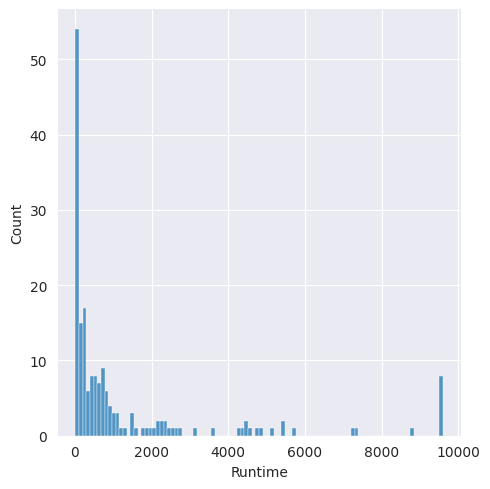

In [86]:
sns.displot(smac3_new_enbumbent, x="Runtime", bins=100)
print(smac3_new_enbumbent["Runtime"].describe())
print(smac3_new_enbumbent["Status"].value_counts())

In [88]:
result_frame_full = pd.merge(default_new_runsolver, smac3_new_enbumbent, how="left", on="File")
display(result_frame_full)
# print(result_frame)

,Unnamed: 0_x,Status_x,Runtime_x,Runlength_x,quality_x,seed_x,File,Unnamed: 0_y,Status_y,Runtime_y,Runlength_y,quality_y,seed_y
0,0,UNSAT,158.555,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,0,UNSAT,110.306,0,0,-1
1,1,UNSAT,323.454,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,1,UNSAT,154.893,0,0,-1
2,2,UNSAT,486.328,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,2,UNSAT,346.081,0,0,-1
3,3,UNSAT,921.222,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,3,UNSAT,563.916,0,0,-1
4,4,UNSAT,991.593,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,6,UNSAT,708.862,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,179,SUCCESS,3780.740,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,179,SUCCESS,4510.430,0,0,-1
180,180,SUCCESS,3153.780,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,180,SUCCESS,4254.980,0,0,-1
181,181,TIMEOUT,9601.050,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,182,TIMEOUT,9601.110,0,0,-1
182,182,SUCCESS,8931.670,0,0,-1,aclib2/instances/mip/data/SDPdMLPa-MIPVerify/m...,181,SUCCESS,7390.350,0,0,-1


Text(0, 0.5, 'Runtime New Config')

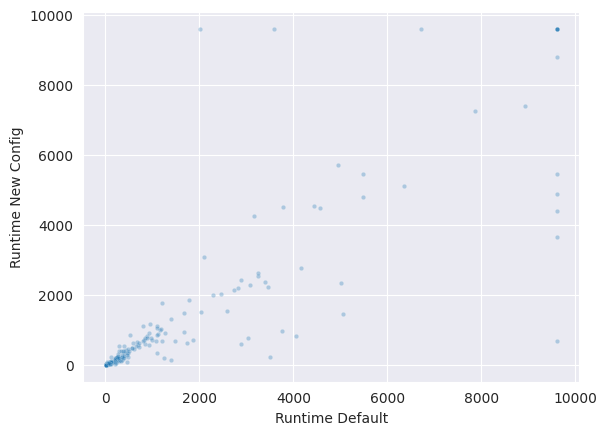

In [84]:
sns.scatterplot(data=result_frame_full, x="Runtime_x", y="Runtime_y", alpha=0.3, s=10)
plt.xlabel("Runtime Default")
plt.ylabel("Runtime New Config")

In [89]:
full_default_runtimes = default_new_runsolver["Runtime"].copy()
full_default_runtimes[full_default_runtimes >= 9600] *= 10
print(full_default_runtimes.mean())

6810.112164673913


In [90]:
full_smac3_runtimes = smac3_new_enbumbent["Runtime"].copy()
full_smac3_runtimes[full_smac3_runtimes >= 9600] *= 10
print(full_smac3_runtimes.mean())

5089.551020597826


# TODO: do a full verificatin run on all instances on the entire dataset....